In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, evaluate_expression

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from typing import Optional
import pickle
import time
from tqdm import tqdm
import matplotlib.ticker as ticker

from data_generation.differential_equations import PoissonSetup2LeastSquares

----------------------------------------
2025-10-15 19:11:22 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup2/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup2/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup2/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup2/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup2/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)

In [3]:
print(f'mesh args: {mesh_args}')
print(f'function space args: {function_space_args}')
print(f'output reduced basis args: {output_reduced_basis_args}')

mesh args: {'lower_left_x': 0.0, 'lower_left_y': 0.0, 'upper_right_x': 1.0, 'upper_right_y': 1.0, 'num_x': 256, 'num_y': 256, 'mesh_cell_type': 'triangle'}
function space args: {'m': {'family': 'CG', 'degree': 1}, 'p': {'family': 'CG', 'degree': 1}, 'u': {'family': 'CG', 'degree': 2}, 'sigma': {'family': 'RT', 'degree': 2}, 'w': {'family': 'CG', 'degree': 2}, 'q': {'family': 'CG', 'degree': 2}}
output reduced basis args: {'num_evals': 1000, 'num_basis': 512}


In [4]:
mesh_args['num_x'] = 256
mesh_args['num_y'] = 256
function_space_args['u']['degree'] = 2 
function_space_args['sigma']['degree'] = 2
function_space_args['w']['degree'] = 2
function_space_args['q']['degree'] = 2

In [5]:
print(f'mesh args: {mesh_args}')
print(f'function space args: {function_space_args}')
print(f'output reduced basis args: {output_reduced_basis_args}')

mesh args: {'lower_left_x': 0.0, 'lower_left_y': 0.0, 'upper_right_x': 1.0, 'upper_right_y': 1.0, 'num_x': 256, 'num_y': 256, 'mesh_cell_type': 'triangle'}
function space args: {'m': {'family': 'CG', 'degree': 1}, 'p': {'family': 'CG', 'degree': 1}, 'u': {'family': 'CG', 'degree': 2}, 'sigma': {'family': 'RT', 'degree': 2}, 'w': {'family': 'CG', 'degree': 2}, 'q': {'family': 'CG', 'degree': 2}}
output reduced basis args: {'num_evals': 1000, 'num_basis': 512}


In [6]:
poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)

In [7]:
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [8]:
print(f'# DoFs of sigma_u: {len(dolfinx.fem.Function(Vh['sigma_u']).x.array)}')

# DoFs of sigma_u: 919553


In [9]:
dataset_path = train_dataset_path
num_samples = 101

if mesh_args['num_x'] == 128 and mesh_args['num_y'] == 128: 
    p_dof = load_npy(dataset_path + "/p_dof.npy")[:num_samples]
elif mesh_args['num_x'] == 256 and mesh_args['num_y'] == 256:
    p_dof = load_npy(dataset_path + "/p_dof_256x256.npy")[:num_samples]

In [10]:
# p = dolfinx.fem.Function(Vh['p'])
# p.x.array[:] = p_dof[0, :]

# x = mesh.geometry.x[:, 0]
# y = mesh.geometry.x[:, 1]

# plt.tricontourf(x, y, evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
# plt.colorbar()
# plt.show()

# dolfinx_mesh_coords = mesh.geometry.x[:,:2]
# num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
# x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
# y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
# image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
# perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]


# p_vertex_values = np.zeros((1, (mesh_args['num_x'] + 1) * (mesh_args['num_y'] + 1)))
# image_p_vertex_values = np.zeros((1, mesh_args['num_y']+1, mesh_args['num_x']+1))

# p_vertex_values[0][perm] = evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0]
# image_p_vertex_values[0] = p_vertex_values[0].reshape(num_x+1, num_y+1).T
# plt.imshow(image_p_vertex_values[0], extent=(0,1,0,1), origin='lower', cmap='turbo')
# plt.colorbar()
# plt.show()

In [11]:
sigma_u_dim = dolfinx.fem.Function(poisson_least_squares.Vh['sigma_u']).x.array.shape[0]
sigma_dim = dolfinx.fem.Function(poisson_least_squares.Vh['sigma']).x.array.shape[0]
u_dim = dolfinx.fem.Function(poisson_least_squares.Vh['u']).x.array.shape[0]
dtype = 'float64'

sigma_u_dof = np.zeros((num_samples, sigma_u_dim), dtype=dtype)
sigma_dof = np.zeros((num_samples, sigma_dim), dtype=dtype)
u_dof = np.zeros((num_samples, u_dim), dtype=dtype)

solve_PDE_time = []
for i in tqdm(range(num_samples)):
    p = dolfinx.fem.Function(poisson_least_squares.Vh['p'], dtype=dtype)
    p.x.array[:] = p_dof[i,:]

    start_time = time.time()
    sigma_u = poisson_least_squares.solve_sigma_u(p=p)
    end_time = time.time()
    solve_PDE_time.append(end_time - start_time)

    sigma = sigma_u.sub(0).collapse()
    u = sigma_u.sub(1).collapse()
    sigma_u_dof[i,:] = sigma_u.x.array
    sigma_dof[i,:] = sigma.x.array
    u_dof[i,:] = u.x.array

100%|██████████| 101/101 [14:48<00:00,  8.79s/it]


In [12]:
print(f'sigma_u_dim: {sigma_u_dim}')
print(f'avg solve time: {np.mean(solve_PDE_time[1:]):.2f} seconds | std: {np.std(solve_PDE_time[1:]):.5f}')

sigma_u_dim: 919553
avg solve time: 8.72 seconds | std: 0.10712


In [13]:
# p = dolfinx.fem.Function(Vh['p'])
# p.x.array[:] = p_dof[0, :]
# p.name = "p"

# sigma_u = dolfinx.fem.Function(Vh['sigma_u'])
# sigma_u.x.array[:] = sigma_u_dof[0, :]
# sigma = sigma_u.sub(0).collapse()
# u = sigma_u.sub(1).collapse()
# sigma.name = "sigma"
# u.name = "u"

In [14]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [15]:
weight_matrices_assemble_time = []
reference_loss_list = []
num_samples_for_reference_loss = num_samples
for i in tqdm(range(num_samples_for_reference_loss)):
    p_fc = dolfinx.fem.Function(Vh['p'])  
    p_fc.x.array[:] = p_dof[i]

    start_time = time.time()
    weight = poisson_least_squares.compute_weight(p_fc)
    end_time = time.time()
    
    weight_matrices_assemble_time.append(end_time - start_time)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])
    y = sigma_u_dof[i]
    y = torch.tensor(y, dtype=torch_dtype['float64'])
    reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'reference loss: {reference_loss.item()}')
    reference_loss_list.append(reference_loss.item())

  1%|          | 1/101 [00:06<11:32,  6.92s/it]

reference loss: 0.0002527180143658825


  2%|▏         | 2/101 [00:14<11:40,  7.08s/it]

reference loss: 0.00025281516988684416


  3%|▎         | 3/101 [00:21<11:30,  7.04s/it]

...

reference loss: 0.0002526296327403088


 99%|█████████▉| 100/101 [11:41<00:06,  6.99s/it]

reference loss: 0.0002530734032006876


100%|██████████| 101/101 [11:48<00:00,  7.02s/it]

reference loss: 0.0002544471764451828


In [16]:
print(f"reference loss mean: {np.mean(reference_loss_list[1:]):.2e}")
print(f"reference loss std: {np.std(reference_loss_list[1:]):.2e}")
print(f"weight matrices assemble time mean: {np.mean(weight_matrices_assemble_time[1:])}")
print(f"weight matrices assemble time std: {np.std(weight_matrices_assemble_time[1:])}")

reference loss mean: 2.53e-04
reference loss std: 2.44e-07
weight matrices assemble time mean: 2.0979544377326964
weight matrices assemble time std: 0.023293892533601302


In [17]:
for i in range(1):
    sigma_u_fc = dolfinx.fem.Function(poisson_least_squares.Vh['sigma_u'])
    sigma_u_fc.x.array[:] = sigma_u_dof[i]
    sigma_fc = sigma_u_fc.sub(0).collapse()
    u_fc = sigma_u_fc.sub(1).collapse()
    sigma_grid_evals = evaluate_expression(mesh, sigma_fc, mesh.geometry.x)[1]
    u_grid_evals = evaluate_expression(mesh, u_fc, mesh.geometry.x)[1] 
    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]

    plt.tricontourf(x, y, u_grid_evals[:, 0], cmap='turbo', levels=100)
    plt.title(fr"$u^{{\circ}}$ (sample {i})")
    plt.colorbar()
    plt.show()

    plt.tricontourf(x, y, sigma_grid_evals[:, 0], cmap='turbo', levels=100)
    plt.title(fr"$\sigma^{{\circ}}_1$ (sample {i})")
    plt.colorbar()
    plt.show()

    plt.tricontourf(x, y, sigma_grid_evals[:, 1], cmap='turbo', levels=100)
    plt.title(fr"$\sigma^{{\circ}}_2$ (sample {i})")
    plt.colorbar()
    plt.show()

KeyboardInterrupt: 

In [ ]:
w = poisson_least_squares.solve_w()
q = poisson_least_squares.solve_q()
z = ufl.grad(q)

In [ ]:
for i in range(1):
    sigma_u_fc = dolfinx.fem.Function(poisson_least_squares.Vh['sigma_u'])
    sigma_u_fc.x.array[:] = sigma_u_dof[i]
    sigma_fc = sigma_u_fc.sub(0).collapse()
    u_fc = sigma_u_fc.sub(1).collapse()
    sigma_grid_evals = evaluate_expression(mesh, sigma_fc, mesh.geometry.x)[1] + evaluate_expression(mesh, z, mesh.geometry.x)[1]
    u_grid_evals = evaluate_expression(mesh, u_fc, mesh.geometry.x)[1] + evaluate_expression(mesh, w, mesh.geometry.x)[1]
    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]

    plt.tricontourf(x, y, u_grid_evals[:, 0], cmap='turbo', levels=100)
    plt.title(fr"$u$ (sample {i})")
    plt.colorbar()
    plt.show()

    plt.tricontourf(x, y, sigma_grid_evals[:, 0], cmap='turbo', levels=100)
    plt.title(fr"$\sigma_1$ (sample {i})")
    plt.colorbar()
    plt.show()

    plt.tricontourf(x, y, sigma_grid_evals[:, 1], cmap='turbo', levels=100)
    plt.title(fr"$\sigma_2$ (sample {i})")
    plt.colorbar()
    plt.show()

### Sanity check for auxiliary variables w and z

In [ ]:
n = ufl.FacetNormal(mesh)
g = poisson_least_squares.g()
ds = poisson_least_squares.ds
mark_id = poisson_least_squares.mark_id
f1 = poisson_least_squares.f1()
f2 = poisson_least_squares.f2()

In [ ]:
z = ufl.grad(q)
print('Validating auxiliary variables...')
temp1 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.div(z), ufl.div(z))*ufl.dx))
print(f'integral ||div(z)||_2^2 dx = {temp1}')

temp2 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(z, n) - g, ufl.dot(z, n) - g) * ds(mark_id["bottom_top"])))
print(f'integral ||z dot n - g||_2^2 ds(bottom & top) = {temp2}')

u0= poisson_least_squares.u0()
temp3 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(u - u0, w - u0) * ds(mark_id["left_right"])))
print(f'integral ||w - u0||_2^2 ds(left & right) = {temp3}')

Validating auxiliary variables...
integral ||div(z)||_2^2 dx = 0.0
integral ||z dot n - g||_2^2 ds(bottom & top) = 0.0
integral ||w - u0||_2^2 ds(left & right) = 9.251858538542962e-17


In [ ]:
print('Validating sigma_u variables...')
temp4 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.div(sigma_fc) + f2, ufl.div(sigma_fc) + f2)*ufl.dx))
print(f'integral ||div(sigma) + f2||_2^2 dx = {temp4}')

temp5 =  dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(u_fc + w - u0, u_fc + w - u0) * ds(mark_id["left_right"])))
print(f'integral ||u + w - u0||_2^2 ds(left & right) = {temp5}')

temp6 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(sigma_fc + z - f1, n) - g, ufl.dot(sigma_fc + z - f1, n) - g) * ds(mark_id["bottom_top"])))
print(f'integral ||(sigma + z - f1) dot n - g||_2^2 ds(bottom & top) = {temp6}') 

temp7 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(sigma_fc + z, n) - g, ufl.dot(sigma_fc + z, n) - g) * ds(mark_id["bottom_top"])))
print(f'integral ||(sigma + z) dot n - g||_2^2 ds(bottom & top) = {temp7}')

temp8 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(sigma_fc, n), ufl.dot(sigma_fc, n)) * ds(mark_id["bottom_top"])))
print(f'integral ||sigma dot n - 0||_2^2 ds(bottom & top) = {temp8}') 

temp9 = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(ufl.dot(p * ufl.grad(u_fc + w), n) - g, ufl.dot(p * ufl.grad(u_fc + w), n) - g) * ds(mark_id["bottom_top"])))
print(f'integral ||(p * grad(u + w)) dot n - g||_2^2 ds(bottom & top) = {temp9}')

Validating sigma_u variables...
integral ||div(sigma) + f2||_2^2 dx = 0.003999569193708479
integral ||u + w - u0||_2^2 ds(left & right) = 3.851100778116392e-32
integral ||(sigma + z - f1) dot n - g||_2^2 ds(bottom & top) = 1.2524619266795821e-31
integral ||(sigma + z) dot n - g||_2^2 ds(bottom & top) = 1.2524619266795821e-31
integral ||sigma dot n - 0||_2^2 ds(bottom & top) = 1.2524619266795821e-31
integral ||(p * grad(u + w)) dot n - g||_2^2 ds(bottom & top) = 0.0001100033853440809


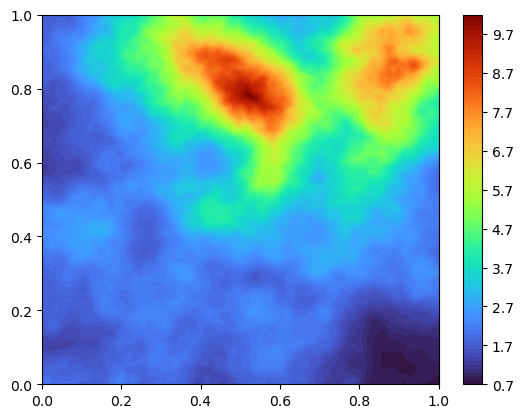

In [ ]:
plt.tricontourf(x, y, evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.show()